# 01 · Sum-to-one: is the basket sum structurally mean-reverting?

In a **mutually exclusive and exhaustive** outcome set (a Polymarket *negRisk* event), exactly one
outcome resolves YES, so the fair probabilities must satisfy

$$\sum_{i=1}^{n} P_i = 1 .$$

Each traded YES price $p_{i,t}$ is a noisy, frictional estimate of $P_i$. This notebook asks whether
the **basket sum** $S_t=\sum_i p_{i,t}$:

1. sits at a stable level (and whether that level is exactly 1 or carries a structural premium or discount);
2. **mean-reverts** while the individual legs wander like random walks (unit-root tests, variance ratios, variograms);
3. reverts fast enough, and by enough, to beat the cost of trading every leg (spreads + taker fees).

The primary basket is the **Fed decision at the October 2026 FOMC** (5 outcomes). Four more live baskets are summarised at the end.

In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from IPython.display import Markdown, display
from src import plotting as P, stats_tools as st, research as R
from src.config import load_markets, get_basket
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.width", 160)
cfg = load_markets()
BASKET = "fed-oct-2026"
ALL = ["fed-oct-2026", "balance-of-power-2026", "house-2026", "senate-2026", "mlb-ws-2026"]
basket = get_basket(BASKET, cfg)

In [2]:
prices, info_prices = R.price_panel(BASKET, cfg)          # REAL /prices-history, 1-minute grid
books = R.book_sums(BASKET, cfg, grid="10s")              # REAL recorded live order books (may be short)
display(Markdown(info_prices.banner_markdown()))
if books is not None:
    display(Markdown(books[2].banner_markdown()))
S = prices.sum(axis=1).rename("S_mid")
DK = info_prices.label

**DATA: REAL Polymarket price history** (`/prices-history`). Prices are real but not executable; wherever execution is simulated, bid/ask/depth are **MODELLED** around them.

| basket | from | to | hours | rows | sessions |
|---|---|---|---|---|---|
| `fed-oct-2026` (Fed Decision in October?) | 2026-09-02T03:01:00 | 2026-10-02T02:59:00 | 720.0 | 43,189 | 1 |

> Execution books are MODELLED: per-leg spread 50-bps-decrease=1 tick(s), 25-bps-decrease=1 tick(s), no-change=1 tick(s), 25-bps-increase=1 tick(s), 50-bps-increase=1 tick(s) (default 1 tick).

**DATA: REAL Polymarket order books** recorded live from the CLOB market WebSocket.

| basket | from | to | hours | rows | sessions |
|---|---|---|---|---|---|
| `fed-oct-2026` (Fed Decision in October?) | 2026-10-01T22:30:10 | 2026-10-02T02:59:25 | 2.5 | 867 | 4 |

> Only 2.5 h of live books so far (recording continues in ≤2 h chunks); treat backtest statistics on this sample as anecdotal.

## 1. The basket

Legs, fee schedules and tick sizes come straight from the Gamma API (`python -m src.discovery add ...`); token ids are never typed by hand.

In [3]:
display(R.basket_overview(cfg, ALL))
display(R.leg_table(basket))

,title,legs,negRisk,augmented,excluded markets,taker fee rate,complete partition,structural discount expected
basket,,,,,,,,
fed-oct-2026,Fed Decision in October?,5,True,False,0,0.0500,True,False
balance-of-power-2026,Balance of Power: 2026 Midterms,5,True,False,0,0.0400,True,False
house-2026,Which party will win the House in 2026?,2,True,True,7,0.0400,False,True
senate-2026,Which party will win the Senate in 2026?,2,True,True,7,0.0400,False,True
mlb-ws-2026,MLB World Series Champion 2026,9,True,True,22,0.0300,False,True


,leg_id,fee rate,fee source,tick,accepting orders
leg,,,,,
50+ bps decrease,50-bps-decrease,0.0500,gamma_feeSchedule,0.0010,True
25 bps decrease,25-bps-decrease,0.0500,gamma_feeSchedule,0.0010,True
No change,no-change,0.0500,gamma_feeSchedule,0.0100,True
25 bps increase,25-bps-increase,0.0500,gamma_feeSchedule,0.0100,True
50+ bps increase,50-bps-increase,0.0500,gamma_feeSchedule,0.0010,True


## 2. Legs drift; the sum stays put

`/prices-history` returns each leg's **order-book midpoint** sampled once a minute (verified against our own recorded books: the sampled
values equal (best bid + best ask)/2). Legs are sampled independently, so an update that hits one leg a few seconds before its
complement creates a transient spike in the sum. That is microstructure noise, not a tradable dislocation, and the tests below have to
tell the two apart.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


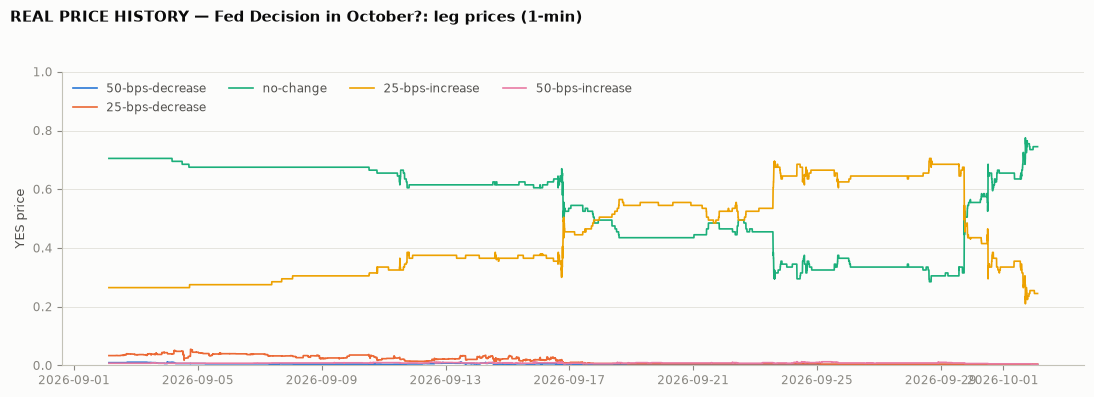

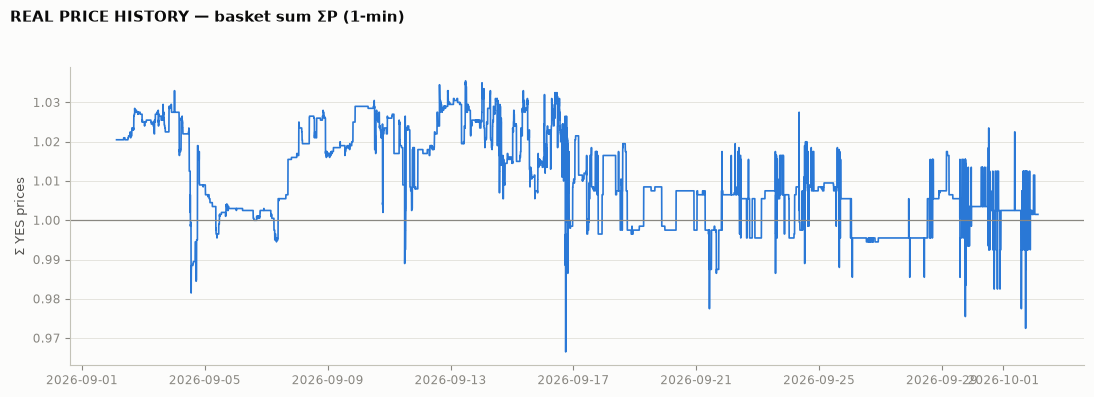

PosixPath('/home/user/bayes_project/results/figures/01_sum_band.png')

In [4]:
P.show(P.plot_legs(prices, data_kind=DK, title=f"{basket.title}: leg prices (1-min)"), "01_legs")
P.show(P.plot_sum_band(pd.DataFrame({"s_mid": S}), data_kind=DK, title="basket sum ΣP (1-min)"), "01_sum_band")

,0.0100,0.0500,0.2500,0.5000,0.7500,0.9500,0.9900
quantile,0.9895,0.9955,1.0025,1.0075,1.0200,1.0290,1.0305


The blueprint's hypothesis that the sum oscillates within **[0.96, 1.05]** holds for **100.0%** of minutes; the observed 1–99% range is **[0.9895, 1.0305]** around a mean of **1.0105**.

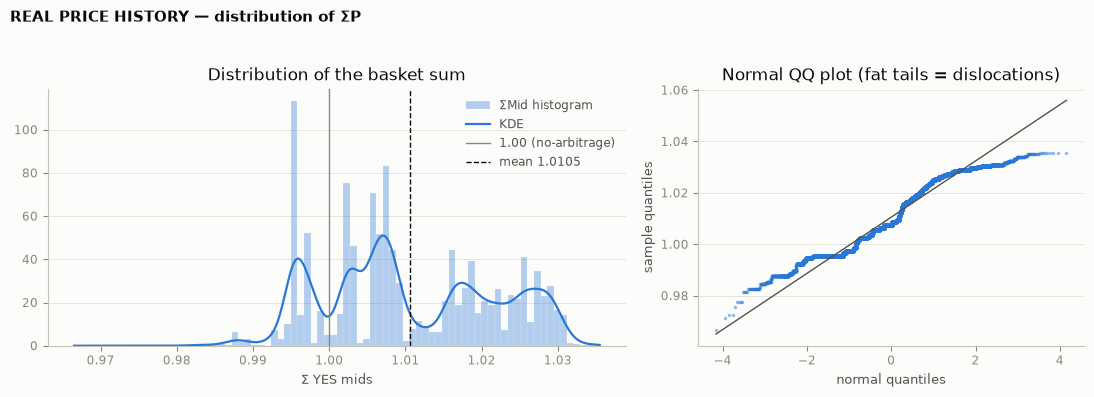

PosixPath('/home/user/bayes_project/results/figures/01_sum_distribution.png')

In [5]:
q = S.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
inside = ((S >= 0.96) & (S <= 1.05)).mean()
display(pd.DataFrame({"quantile": q}).T)
display(Markdown(f"The blueprint's hypothesis that the sum oscillates within **[0.96, 1.05]** holds for **{inside:.1%}** of minutes; "
                 f"the observed 1–99% range is **[{q[0.01]:.4f}, {q[0.99]:.4f}]** around a mean of **{S.mean():.4f}**."))
P.show(P.plot_sum_distribution(S, data_kind=DK, title="distribution of ΣP"), "01_sum_distribution")

## 3. Unit-root tests: legs vs sum

* **ADF** (H0: unit root) and **KPSS** (H0: stationary) are run on every leg (in price and in logit) and on $S$; ADF p-values are Holm-adjusted across the family.
* Reading the 2×2 table: ADF rejects + KPSS does not → *stationary*; ADF does not reject + KPSS rejects → *unit root*; both reject → *inconclusive*
  (typical of a series that mean-reverts but slowly, or has occasional level shifts).
* Long-shot legs pinned near the 0.001 tick floor look "stationary" only because they cannot move; they are flagged and excluded from the "legs are I(1)" claim.

In [6]:
series = {f"leg: {c}": prices[c] for c in prices.columns}
series.update({f"logit: {c}": np.log(prices[c].clip(1e-4, 1 - 1e-4) / (1 - prices[c].clip(1e-4, 1 - 1e-4)))
               for c in prices.columns if prices[c].mean() > 0.02})
series["SUM S = Σp"] = S
ur = R.unit_root_table(series)
ur["pinned long shot (<0.02)"] = [n.startswith("leg:") and prices[n[5:]].mean() < 0.02 for n in ur.index]
display(ur)

,mean,std,ADF stat,ADF p,KPSS p,ADF p (Holm),verdict,mean-reverting (ADF),pinned long shot (<0.02)
series,,,,,,,,,
leg: 50-bps-decrease,0.0044,0.0021,-3.1872,0.0207,<0.01,0.1244,unit_root,False,True
leg: 25-bps-decrease,0.0172,0.0137,-2.1594,0.2213,<0.01,1.0000,unit_root,False,True
leg: no-change,0.5453,0.1378,-1.0807,0.7227,<0.01,1.0000,unit_root,False,False
leg: 25-bps-increase,0.4354,0.1439,-1.1424,0.6979,<0.01,1.0000,unit_root,False,False
leg: 50-bps-increase,0.0083,0.0013,-4.0403,0.0012,<0.01,0.0085,inconclusive,True,True
logit: no-change,0.1897,0.5752,-1.0710,0.7265,<0.01,1.0000,unit_root,False,False
logit: 25-bps-increase,-0.2775,0.6073,-1.1351,0.7009,<0.01,1.0000,unit_root,False,False
SUM S = Σp,1.0105,0.0112,-5.1340,0.0000,<0.01,0.0001,inconclusive,True,False


## 4. Variance ratios, variogram and autocorrelation

For a random walk $\mathrm{Var}(x_t-x_{t-q})$ grows linearly in $q$ and the variance ratio $VR(q)\approx 1$; for a stationary AR(1) it levels off at
$2\gamma_0$ and $VR(q)\to 0$ like $1/q$. Pure quote noise on top of a random walk would instead make $VR$ drop quickly to a *plateau* below 1.

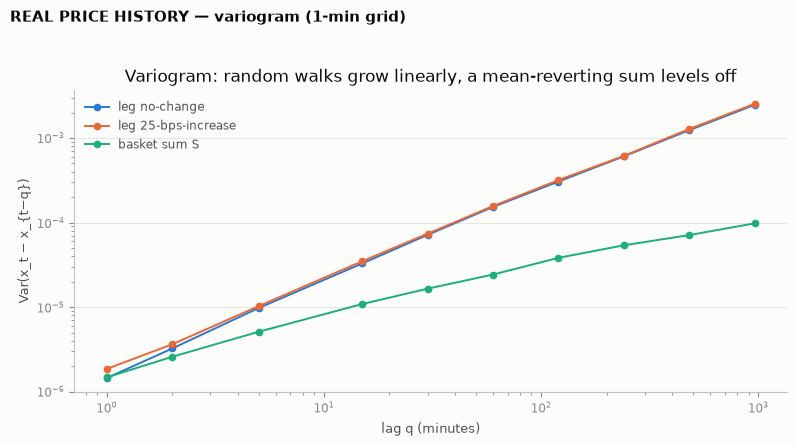

,VR(2),VR(5),VR(15),VR(60),VR(240)
series,,,,,
leg no-change,1.1172,1.3465,1.5120,1.7622,1.7552
leg 25-bps-increase,0.9764,1.1047,1.2538,1.4100,1.3861
basket sum S,0.8750,0.6921,0.4914,0.2745,0.1527


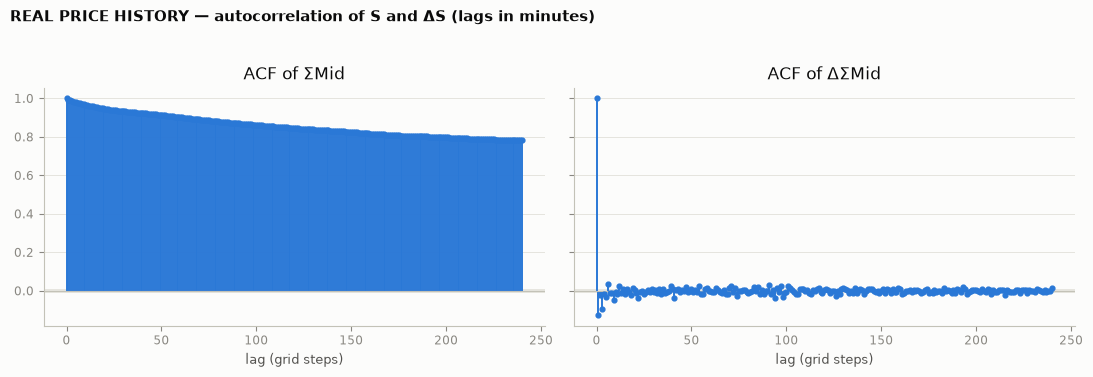

PosixPath('/home/user/bayes_project/results/figures/01_acf.png')

In [7]:
lags = [1, 2, 5, 15, 30, 60, 120, 240, 480, 960]
big = [c for c in prices.columns if prices[c].mean() > 0.02]
curves = {f"leg {c}": (lags, st.variogram(prices[c].to_numpy(), lags)) for c in big}
curves["basket sum S"] = (lags, st.variogram(S.to_numpy(), lags))
P.show(P.plot_variogram(curves, data_kind=DK, title="variogram (1-min grid)"), "01_variogram")
display(R.variance_ratio_table({**{f"leg {c}": prices[c] for c in big}, "basket sum S": S}))
P.show(P.plot_acf_pair(S, nlags=240, data_kind=DK, title="autocorrelation of S and ΔS (lags in minutes)"), "01_acf")

## 5. Speed of mean reversion: AR(1) / Ornstein–Uhlenbeck half-life

$S_t = c + \phi S_{t-1} + \varepsilon_t$ with half-life $h = -\ln 2/\ln\phi$ grid steps. If the half-life were about one grid step at every
sampling interval we would be measuring bid–ask bounce, not dislocation decay, so it is re-estimated on 1, 5 and 15-minute grids (it should
be roughly invariant in clock time). Confidence intervals: delta method and a stationary block bootstrap.

In [8]:
hl = R.half_life_table(S, n_boot=200)
display(hl)

,phi,half-life (min),delta-method SE (min),bootstrap 95% lo (min),bootstrap 95% hi (min),sigma_inf,n
grid,,,,,,,
1min,0.9941,117.4770,14.1238,88.3433,158.8523,0.0112,43188
5min,0.9796,168.5568,26.1283,117.4829,251.9635,0.0112,8638
15min,0.9555,228.1813,38.8969,157.6467,381.9117,0.0112,2879


## 6. Is the level exactly 1? (structural premium / discount)

$H_0: E[S]=1$ is tested with Newey–West (HAC) standard errors because $S$ is strongly autocorrelated. Reasons the level can differ from 1:
the half-spread bias of long-shot mids near the tick floor, the favourite–long-shot bias, capital lock-up until resolution (pushes asks
below 1), and for *augmented* events the unnamed "Other" outcomes (named legs sum to less than 1).

In [9]:
h = st.hac_mean_test(S, 1.0)
display(pd.DataFrame([h]))
direction = "premium (overround)" if h["mean"] > 1 else "discount"
display(Markdown(f"Mean ΣP = **{h['mean']:.4f}** (HAC t = {h['t']:.2f}, p = {R.fmt_p(h['pvalue'])}): "
                 + (f"a statistically significant **{direction}** of {abs(h['mean'] - 1) * 100:.2f} cents per basket."
                    if h["pvalue"] < 0.05 else "not significantly different from 1.")))

,mean,t,pvalue,se,lags,nobs
0,1.0105,7.5013,0.0000,0.0014,862,43189


Mean ΣP = **1.0105** (HAC t = 7.50, p = <1e-4): a statistically significant **premium (overround)** of 1.05 cents per basket.

## 7. What can actually be traded: the executable band from live order books

Mids are not tradable. Buying one YES of every leg costs $S_{ask}=\sum a_i$; buying one NO of every leg costs $n-S_{bid}$ (NO asks mirror
YES bids) and pays $n-1$. A riskless taker trade therefore needs $S_{ask}<1$ or $S_{bid}>1$ (before fees). The band
$[S_{bid}, S_{ask}]$ is at least $n$ ticks wide.

,rows,share S_ask<1,share S_bid>1,share S_ask<1-fees,share S_bid>1+fees,median spread_sum,min S_ask,max S_bid
0,815,0.0000,0.0000,0.0000,0.0000,0.0230,1.0130,0.9900


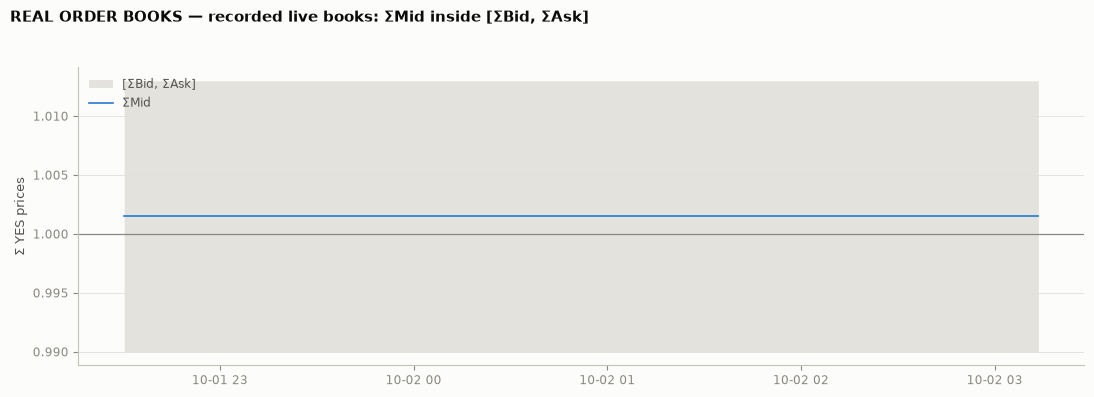

In [10]:
if books is not None:
    sums, seg, binfo = books
    bs = R.band_stats(sums, basket)
    display(pd.DataFrame([bs]))
    P.show(P.plot_sum_band(sums.dropna(subset=["s_mid"]), data_kind=binfo.label,
                           title="recorded live books: ΣMid inside [ΣBid, ΣAsk]"), "01_live_band")
else:
    display(Markdown("_No recorded order books yet for this basket._"))

## 8. Five live baskets side by side, and the cost hurdle (interview pro-tip 2)

A z-score round trip on the mid-sum must clear the n-leg spread plus entry and exit taker fees
(fee per unit $F=\sum_i r_i p_i(1-p_i)\approx r(1-\sum p_i^2)$). The **edge-to-cost ratio** $ECR=\sigma(S)/\text{hurdle}$ says how many hurdles
a typical excursion spans: liquid, tight baskets rank first; crypto carries the highest fee rate (0.07).

In [11]:
stats_all = R.basket_stats_table(cfg, ALL)
display(stats_all)
hurdles = R.hurdle_table(cfg, ALL)
display(hurdles)

,legs,minutes,mean ΣP,sd ΣP,q01,q99,ADF p,KPSS p,half-life (min),HAC t (mean=1),augmented,ADF p (Holm),verdict
basket,,,,,,,,,,,,,
fed-oct-2026,5,43189,1.0105,0.0112,0.9895,1.0305,0.0000,<0.01,117.4770,7.5013,False,0.0000,inconclusive
balance-of-power-2026,5,43188,0.9994,0.0136,0.9760,1.0270,0.0027,<0.01,616.1979,-0.3416,False,0.0055,inconclusive
house-2026,2,43190,1.0039,0.0055,0.9900,1.0100,0.0000,<0.01,305.2337,6.4220,True,0.0000,inconclusive
senate-2026,2,43190,1.0044,0.0064,0.9900,1.0100,0.0004,<0.01,376.7842,5.4726,True,0.0012,inconclusive
mlb-ws-2026,9,43188,0.8624,0.0489,0.7680,1.0215,0.9199,<0.01,2034.7228,-20.5721,True,0.9199,unit_root


/home/user/bayes_project/data/historical_books/main/raw/2026-10-02/03-20261002T025925Z-1d41.jsonl.gz: truncated/corrupt gzip tail (EOFError); stopping this file


crossed book 6302359956133594764084277082169634158291609371270652093164054687145970756151: bid=290000 ask=290000


/home/user/bayes_project/data/historical_books/main/raw/2026-10-02/03-20261002T025925Z-1d41.jsonl.gz: truncated/corrupt gzip tail (EOFError); stopping this file


/home/user/bayes_project/data/historical_books/main/raw/2026-10-02/03-20261002T025925Z-1d41.jsonl.gz: truncated/corrupt gzip tail (EOFError); stopping this file


...

desync 56772567436880230751429990016212879028273056769219355099340259163330517784781: ours=(4000, 16000) server=(1000, 16000) after 3 frames


desync 31221080242705278649725019814790252911735511309312424063267127209870268745118: ours=(91000, 103000) server=(84000, 103000) after 3 frames


crossed book 87400549613971964996449731299293585289302880817247437384669548139968257881468: bid=96000 ask=96000


/home/user/bayes_project/data/historical_books/main/raw/2026-10-02/03-20261002T025925Z-1d41.jsonl.gz: truncated/corrupt gzip tail (EOFError); stopping this file


,spread_sum,spread source,fee/unit F,round-trip hurdle,sd ΣP (1-min),ECR = sd/hurdle
basket,,,,,,
fed-oct-2026,0.0230,recorded books,0.0265,0.0753,0.0112,0.1487
balance-of-power-2026,0.0330,recorded books,0.0230,0.0783,0.0136,0.1732
house-2026,0.0200,recorded books,0.0075,0.0350,0.0055,0.1576
senate-2026,0.0200,recorded books,0.0196,0.0592,0.0064,0.1087
mlb-ws-2026,0.0660,recorded books,0.0223,0.1091,0.0489,0.4483


In [12]:
row = stats_all.loc[BASKET]
legs_big = [n for n in ur.index if n.startswith("leg:") and not ur.loc[n, "pinned long shot (<0.02)"]]
legs_ur = [n for n in legs_big if not ur.loc[n, "mean-reverting (ADF)"]]
hl1 = hl.loc["1min", "half-life (min)"]
ecr = hurdles.loc[BASKET, "ECR = sd/hurdle"] if BASKET in hurdles.index else float("nan")
lines = [
    f"* **Legs wander, the sum does not.** {len(legs_ur)} of {len(legs_big)} liquid legs fail to reject a unit root (ADF, Holm), "
    f"while ADF on S rejects with p = {R.fmt_p(row['ADF p (Holm)'])}. KPSS also rejects for S (p {row['KPSS p']}), so the formal verdict is "
    f"'{row['verdict']}': S is mean-reverting but highly persistent (slow decay plus level shifts at news), not white noise around 1.",
    f"* **Speed.** AR(1) half-life ≈ **{hl1:.0f} minutes** on the 1-minute grid ({hl.loc['5min','half-life (min)']:.0f} / "
    f"{hl.loc['15min','half-life (min)']:.0f} min on 5 / 15-minute grids): dislocations take hours, not seconds, to decay.",
    f"* **Level.** Mean ΣP = {row['mean ΣP']:.4f} (HAC t = {row['HAC t (mean=1)']:.1f}): a structural {'premium' if row['mean ΣP'] > 1 else 'discount'}, "
    f"which is why the engine z-scores S against a *rolling* mean rather than against 1.00.",
    f"* **Costs dominate.** A taker round trip must clear ≈ {hurdles.loc[BASKET,'round-trip hurdle']:.3f} per basket, while the typical "
    f"1-minute dispersion of S is {row['sd ΣP']:.4f} (ECR = {ecr:.2f}). Mean reversion is real, but most of it happens *inside* the no-arbitrage band.",
]
if books is not None:
    lines.append(f"* **Live books.** Over the recorded hours S_ask never fell below 1 (min {bs['min S_ask']:.3f}) and S_bid never exceeded 1 "
                 f"(max {bs['max S_bid']:.3f}): no riskless taker arbitrage was available in that window.")
display(Markdown("### Conclusions (generated from the numbers above)\n" + "\n".join(lines)))

### Conclusions (generated from the numbers above)
* **Legs wander, the sum does not.** 2 of 2 liquid legs fail to reject a unit root (ADF, Holm), while ADF on S rejects with p = <1e-4. KPSS also rejects for S (p <0.01), so the formal verdict is 'inconclusive': S is mean-reverting but highly persistent (slow decay plus level shifts at news), not white noise around 1.
* **Speed.** AR(1) half-life ≈ **117 minutes** on the 1-minute grid (169 / 228 min on 5 / 15-minute grids): dislocations take hours, not seconds, to decay.
* **Level.** Mean ΣP = 1.0105 (HAC t = 7.5): a structural premium, which is why the engine z-scores S against a *rolling* mean rather than against 1.00.
* **Costs dominate.** A taker round trip must clear ≈ 0.075 per basket, while the typical 1-minute dispersion of S is 0.0112 (ECR = 0.15). Mean reversion is real, but most of it happens *inside* the no-arbitrage band.
* **Live books.** Over the recorded hours S_ask never fell below 1 (min 1.013) and S_bid never exceeded 1 (max 0.990): no riskless taker arbitrage was available in that window.

### Limitations
* `/prices-history` mids are sampled per leg once a minute; asynchronous sampling inflates the measured dispersion of S at short horizons.
* Thirty days of 1-minute data for one event is one realisation; news (CPI, FOMC communication) creates level shifts that unit-root tests read as persistence.
* MLB: legs eliminated during the window resolve NO; the sum of the *currently open* legs is therefore not a fixed basket over history (its unit root is a composition effect).
* House/Senate are *augmented* negRisk events: named legs exclude inactive placeholders, so their sum carries P(unnamed outcome).

In [13]:
infos = [info_prices] + ([books[2]] if books is not None else [])
R.save_dataset_info("01", infos, {"basket_stats": stats_all.reset_index().to_dict("records"),
                                   "half_life_min": float(hl1), "hurdles": hurdles.reset_index().to_dict("records")})
print("saved results/dataset_info_01.json; figures in results/figures/01_*.png")

saved results/dataset_info_01.json; figures in results/figures/01_*.png
